In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_3488149/3716655788.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


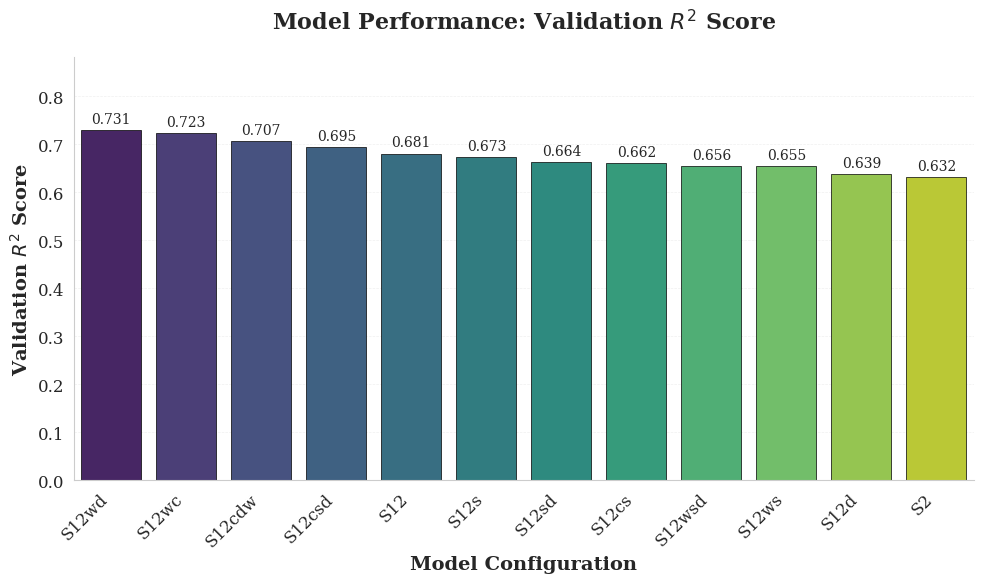

/tmp/ipykernel_3488149/3716655788.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


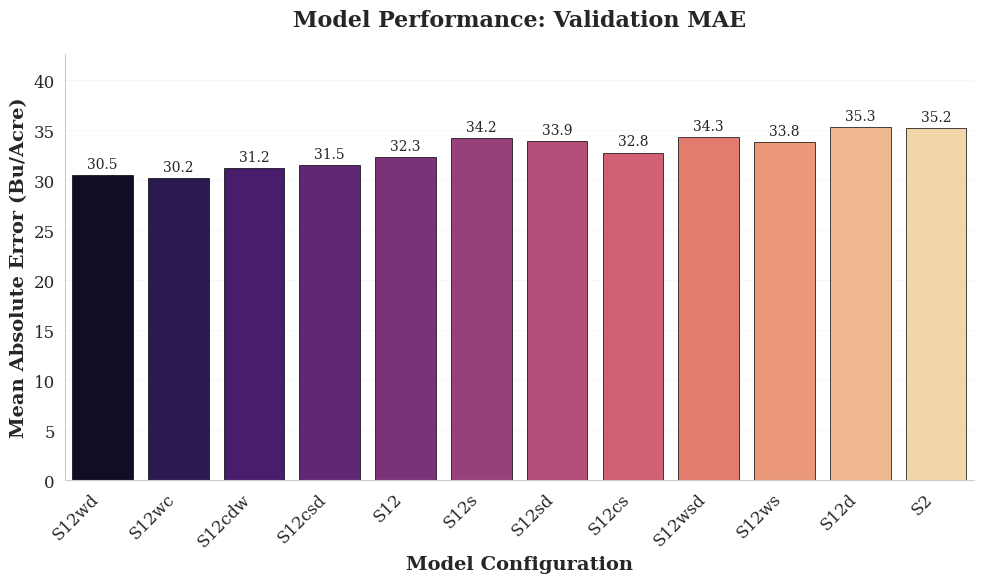

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("Modality_Config.csv")

# Filter out rows with missing val/R2_Score
df = df[df["val/R2_Score"].notnull()]

# Ignore repeats
df = df.drop_duplicates(subset="Name", keep="first")

# Sort by val/R2_Score descending for better visualization
df = df.sort_values("val/R2_Score", ascending=False)
df['val/MAE'] = df['val/MAE'] * 550

# Create short labels by splitting on '-' and taking first component
df['Short_Name'] = df['Name'].str.split('-').str[0]

# Set publication-ready style
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 16

# Plot Validation R²
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=df,
    x="Short_Name",
    y="val/R2_Score",
    palette="viridis",
    ax=ax,
    edgecolor='black',
    linewidth=0.5
)
# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=10)
ax.set_xlabel("Model Configuration", fontsize=14, fontweight='bold')
ax.set_ylabel("Validation $R^2$ Score", fontsize=14, fontweight='bold')
ax.set_title("Model Performance: Validation $R^2$ Score", fontsize=16, fontweight='bold', pad=20)
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("val_r2_by_experiment.pdf", bbox_inches="tight", dpi=300)
plt.savefig("val_r2_by_experiment.png", bbox_inches="tight", dpi=300)
plt.show()

# Plot Validation MAE
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=df,
    x="Short_Name",
    y="val/MAE",
    palette="magma",
    ax=ax,
    edgecolor='black',
    linewidth=0.5
)
# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=10)
ax.set_xlabel("Model Configuration", fontsize=14, fontweight='bold')
ax.set_ylabel("Mean Absolute Error (Bu/Acre)", fontsize=14, fontweight='bold')
ax.set_title("Model Performance: Validation MAE", fontsize=16, fontweight='bold', pad=20)
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("val_mae_by_experiment.pdf", bbox_inches="tight", dpi=300)
plt.savefig("val_mae_by_experiment.png", bbox_inches="tight", dpi=300)
plt.show()

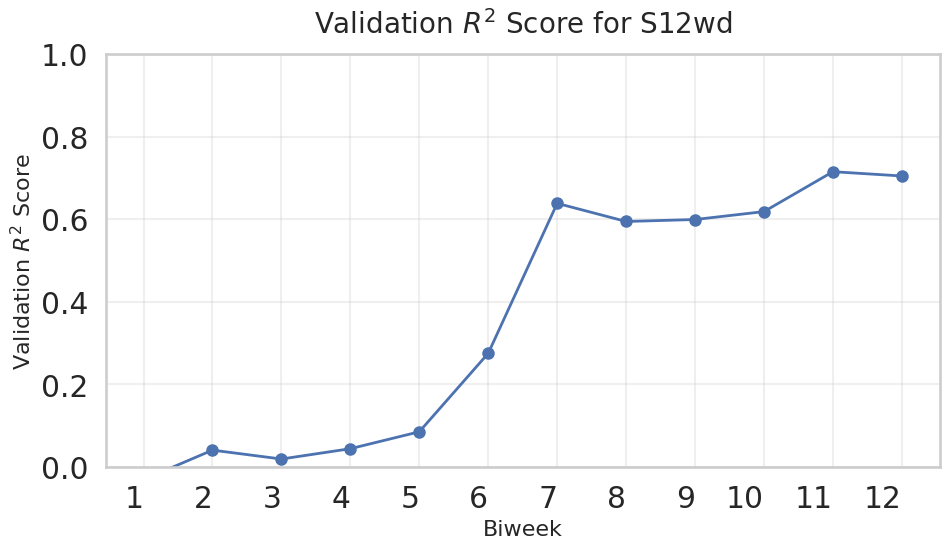

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file
df = pd.read_csv("Terramind_test.csv")

# Convert validation R2 column to numeric (handles any missing/empty values)
df["val/R2_Score"] = pd.to_numeric(df["val/R2_Score"], errors='coerce')
# Reverse the order
df = df.iloc[::-1].reset_index(drop=True)
# Create numeric index for x-axis
df = df.reset_index(drop=True)
df['index'] = range(len(df))


# Create short labels by splitting on '_' and taking second component
df['Short_Name'] = df['Name'].str.split('_').str[1]
# Set seaborn style for publication
sns.set(style="whitegrid", context="talk", font_scale=1.3)

plt.figure(figsize=(10, 6))
plt.plot(df['index'], df["val/R2_Score"], marker="o", linewidth=2, markersize=8)
plt.title(f"Validation $R^2$ Score for {df['Name'].iloc[0].split('_')[0]}", fontsize=20, pad=15)
plt.xlabel("Biweek", fontsize=16)
plt.ylabel("Validation $R^2$ Score", fontsize=16)
plt.xticks(df['index'], df['Short_Name'], ha='right')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("val_r2_lineplot.pdf", bbox_inches='tight', dpi=300)
plt.show()

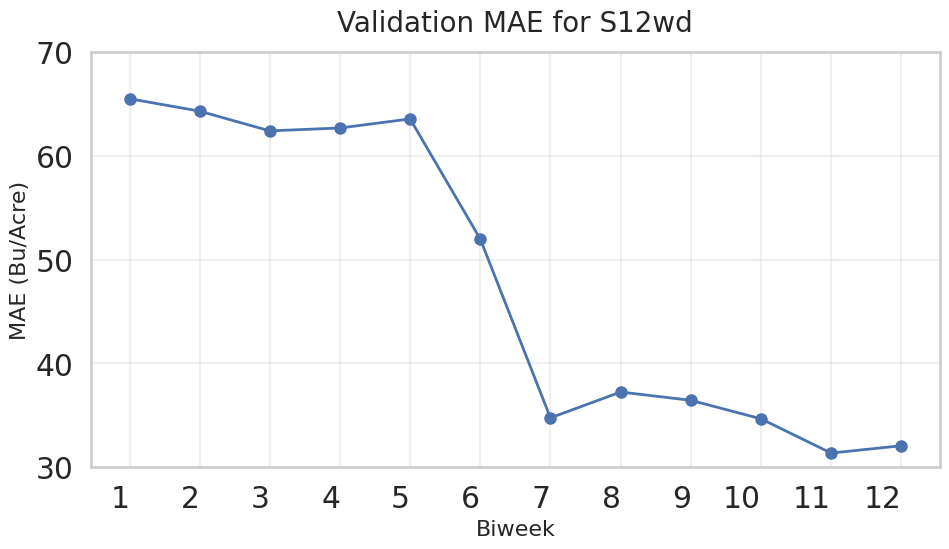

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file
df = pd.read_csv("Terramind_test.csv")

# Convert validation MAE column to numeric (handles any missing/empty values)
df["val/MAE"] = pd.to_numeric(df["val/MAE"], errors='coerce')
df["val/MAE"] = df["val/MAE"]*550  # Scale MAE if needed
# Reverse the order
df = df.iloc[::-1].reset_index(drop=True)

# Create short labels by splitting on '_' and taking second component
df['Short_Name'] = df['Name'].str.split('_').str[1]
# Create numeric index for x-axis
df = df.reset_index(drop=True)
df['index'] = range(len(df))

# Set seaborn style for publication
sns.set(style="whitegrid", context="talk", font_scale=1.3)

plt.figure(figsize=(10, 6))
plt.plot(df['index'], df["val/MAE"], marker="o", linewidth=2, markersize=8)
plt.ylim(30, 70)
plt.title(f"Validation MAE for {df['Name'].iloc[0].split('_')[0]}", fontsize=20, pad=15)
plt.xlabel("Biweek", fontsize=16)
plt.ylabel("MAE (Bu/Acre)", fontsize=16)
plt.xticks(df['index'], df['Short_Name'], ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("val_mae_lineplot.pdf", bbox_inches='tight', dpi=300)
plt.show()